# Credit Risk — Full Pipeline
**الترتيب:** Load → EDA → Cleaning → Split → Preprocessing (Encoding + Imputation + Scaling) → Imbalance → Models → Imputer comparison → Tuning → Evaluation → Saving

> كل الـ fit (imputer / scaler / encoder) بيحصل جوه الـ `Pipeline` على الـ train بس → مفيش Data Leakage.

# 1. Imports & Setup

In [ ]:
import json
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_validate, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder,LabelEncoder,
                                   StandardScaler)
from xgboost import XGBClassifier

# لازم الفولدر يتعمل قبل أي save (كان ناقص وكان هيدي FileNotFoundError)
os.makedirs("artifacts", exist_ok=True)

# 2. Load Data

In [ ]:
# على Colab غيّر المسار لـ "/content/credit_risk_dataset.csv"
DATA_PATH = "credit_risk_dataset.csv"
data = pd.read_csv(DATA_PATH)

# 3. EDA

In [ ]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
data.shape

(32581, 12)

In [ ]:
data.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [ ]:
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
data['person_emp_length'].unique()   # لاحظ القيمة 123 سنة

array([123.,   5.,   1.,   4.,   8.,   2.,   6.,   7.,   0.,   9.,   3.,
        10.,  nan,  11.,  18.,  12.,  17.,  14.,  16.,  13.,  19.,  15.,
        20.,  22.,  21.,  24.,  23.,  26.,  25.,  27.,  28.,  31.,  41.,
        34.,  29.,  38.,  30.])

In [ ]:
# imbalance check
data['loan_status'].value_counts(normalize=True) * 100

,proportion
loan_status,
0,78.183604
1,21.816396


In [ ]:
num_cols = data.select_dtypes(include='number').columns.to_list()
num_cols.remove('loan_status')
cat_cols = data.select_dtypes(exclude='number').columns.to_list()
print(num_cols)
print(cat_cols)

['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


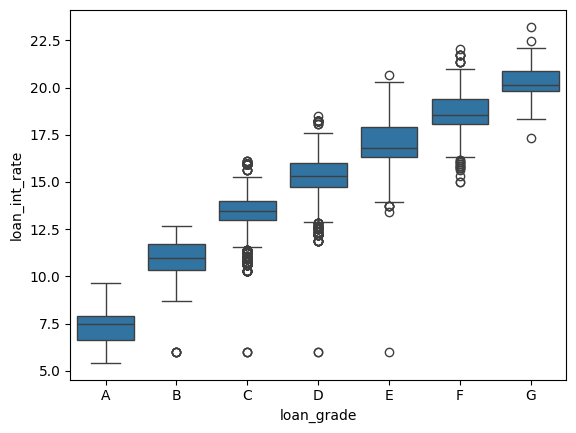

In [ ]:
sns.boxplot(data=data, x="loan_grade", y="loan_int_rate", order=list("ABCDEFG"))
plt.show()

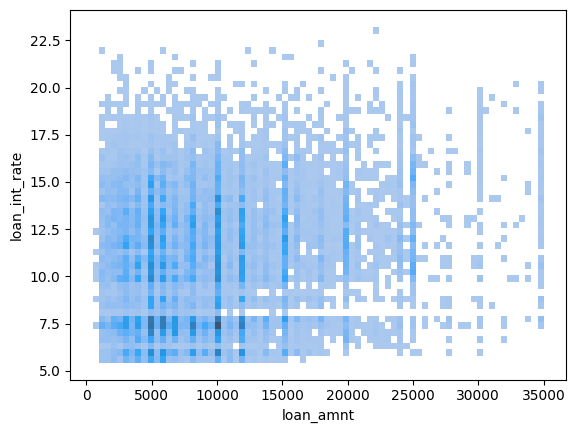

In [ ]:
# loan_amnt vs loan_int_rate (2D histogram لأن البيانات كتير)
sns.histplot(data=data, x='loan_amnt', y='loan_int_rate')
plt.show()

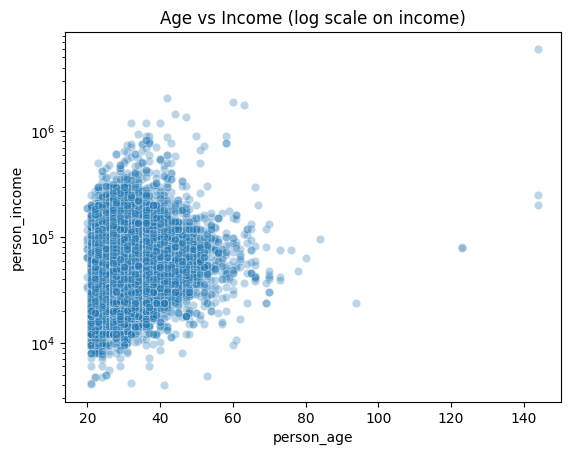

In [ ]:
# age vs income: الدخل عنده ذيل طويل جدًا (لحد 6 مليون)، فبنستخدم log scale عشان النقط متتكدسش تحت
sns.scatterplot(data=data, x='person_age', y='person_income', alpha=0.3)
plt.yscale('log')
plt.title("Age vs Income (log scale on income)")
plt.show()

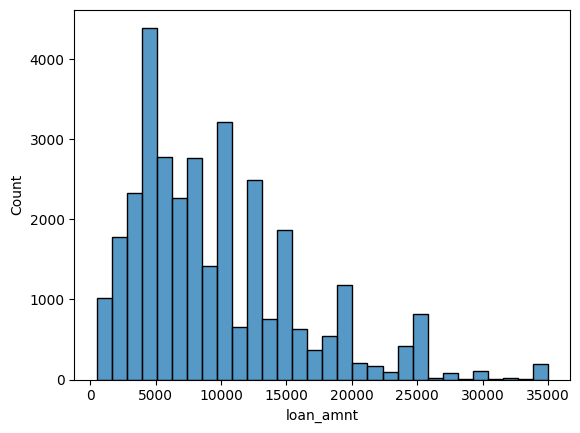

In [ ]:
sns.histplot(data=data, x='loan_amnt', bins=30)
plt.show()

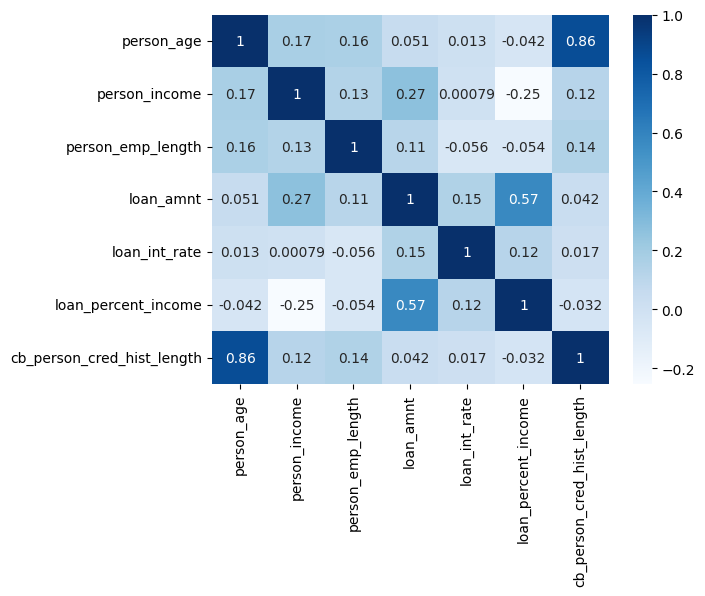

In [ ]:
correlations = data[num_cols].corr()
sns.heatmap(correlations, annot=True, cmap="Blues")
plt.show()
# أقوى علاقة: person_age × cb_person_cred_hist_length (الاتنين مرتبطين بالزمن)

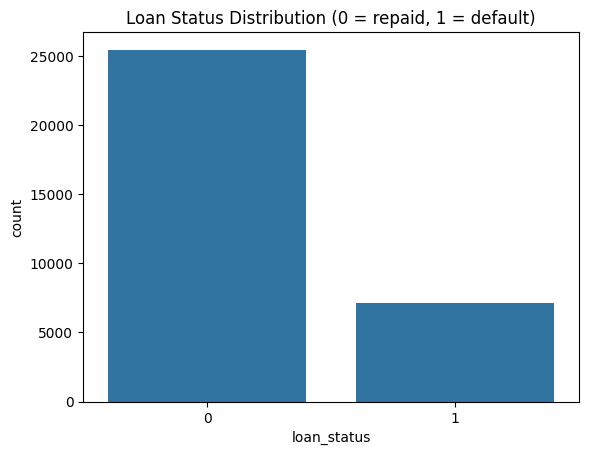

In [ ]:
sns.countplot(data=data, x="loan_status")
plt.title("Loan Status Distribution (0 = repaid, 1 = default)")
plt.show()

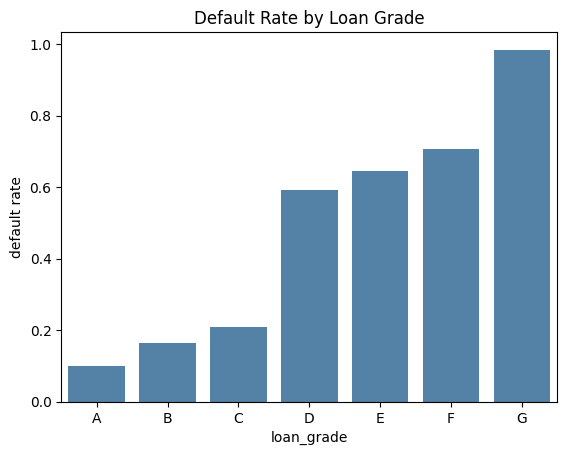

In [ ]:
grade_default = data.groupby("loan_grade")["loan_status"].mean().sort_index()
sns.barplot(x=grade_default.index, y=grade_default.values, color="steelblue")
plt.title("Default Rate by Loan Grade"); plt.ylabel("default rate")
plt.show()

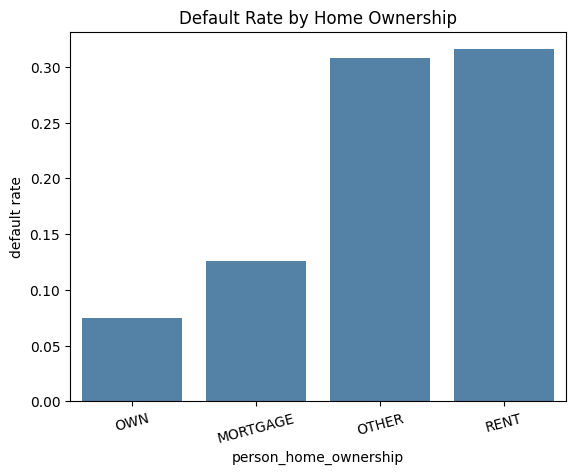

In [ ]:
own_default = data.groupby("person_home_ownership")["loan_status"].mean().sort_values()
sns.barplot(x=own_default.index, y=own_default.values, color="steelblue")
plt.title("Default Rate by Home Ownership"); plt.ylabel("default rate")
plt.xticks(rotation=15)
plt.show()

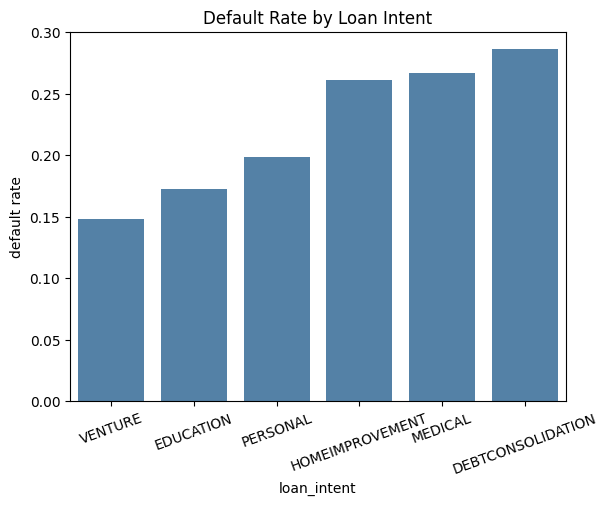

In [ ]:
intent_default = data.groupby("loan_intent")["loan_status"].mean().sort_values()
sns.barplot(x=intent_default.index, y=intent_default.values, color="steelblue")
plt.title("Default Rate by Loan Intent"); plt.ylabel("default rate")
plt.xticks(rotation=20)
plt.show()

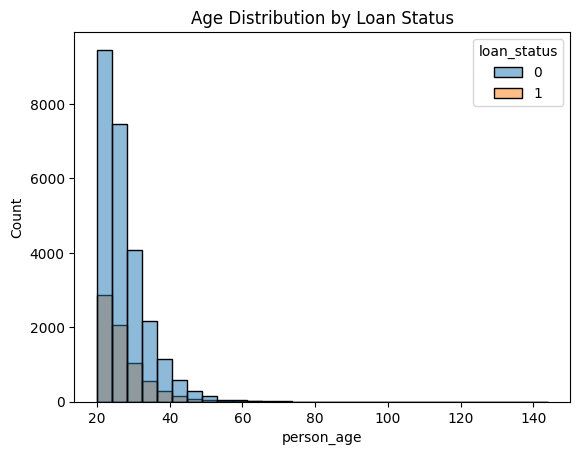

In [ ]:
sns.histplot(data=data, x="person_age", hue="loan_status", bins=30)
plt.title("Age Distribution by Loan Status")
plt.show()

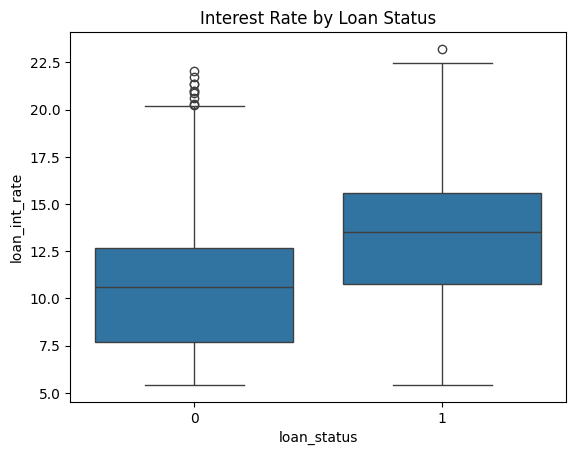

In [ ]:
sns.boxplot(data=data, x="loan_status", y="loan_int_rate")
plt.title("Interest Rate by Loan Status")
plt.show()

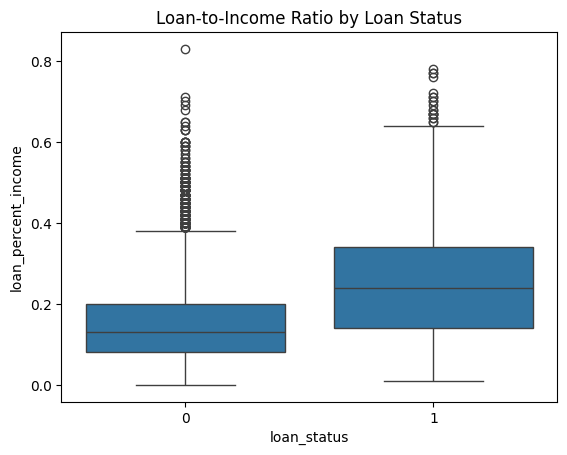

In [ ]:
sns.boxplot(data=data, x="loan_status", y="loan_percent_income")
plt.title("Loan-to-Income Ratio by Loan Status")
plt.show()

# 4. Data Cleaning
- الـ **nulls** (في `person_emp_length` و `loan_int_rate`) هتتعالج جوه الـ Pipeline **بعد الـ split** (fit على الـ train بس).
- الـ **outliers المنطقية** بنعالجها بقواعد ثابتة (مش إحصائيات)، فمفيش leakage لو اتعملت قبل الـ split.

In [ ]:
print("duplicates before:", data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)
print("duplicates after:", data.duplicated().sum())

duplicates before: 165
duplicates after: 0


In [ ]:
# عدد الـ IQR outliers (للمعلومة بس — مش هنحذفهم: أغلبهم قيم حقيقية زي دخل عالي،
# والموديل اللي بنستخدمه tree-based مش حساس ليهم)
for col in num_cols:
    Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((data[col] < Q1 - 1.5 * IQR) | (data[col] > Q3 + 1.5 * IQR)).sum()
    print(f"{col}: {n} outliers")

person_age: 1491 outliers
person_income: 1478 outliers
person_emp_length: 852 outliers
loan_amnt: 1679 outliers
loan_int_rate: 6 outliers
loan_percent_income: 650 outliers
cb_person_cred_hist_length: 1139 outliers


In [ ]:
# قيم مستحيلة منطقيًا (عمر > 100 سنة، أو سنين شغل > 60 سنة) -> نحذفها
# (NaN > 60 بتدي False فالصفوف اللي فيها nulls مش بتتحذف)
impossible = (data['person_age'] > 100) | (data['person_emp_length'] > 60)
print("impossible rows:", impossible.sum())
print(data.loc[impossible, ['person_age', 'person_emp_length']])
data = data[~impossible].reset_index(drop=True)

impossible rows: 7
       person_age  person_emp_length
0              22              123.0
81            144                4.0
183           144                4.0
210            21              123.0
575           123                2.0
747           123                7.0
32132         144               12.0


In [ ]:
# loan_percent_income = 0.0 مش منطقي: السبب إن العمود متقرب لرقمين عشريين (قرض صغير / دخل كبير)
# -> نعيد حسابها للصفوف دي بس بدون تقريب
zero_mask = data['loan_percent_income'] == 0
print("zero rows:", zero_mask.sum())
data.loc[zero_mask, 'loan_percent_income'] = (
    data.loc[zero_mask, 'loan_amnt'] / data.loc[zero_mask, 'person_income'])
print("zero rows after:", (data['loan_percent_income'] == 0).sum())

zero rows: 8
zero rows after: 0


In [ ]:
print(data.shape)
data.isna().sum()

(32409, 12)


,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,887
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3094
loan_status,0
loan_percent_income,0


# 5. Train / Test Split

In [ ]:
X = data.drop('loan_status', axis=1)
y = data['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (25927, 11) | test: (6482, 11)


In [ ]:
DEFAULT_COL = "cb_person_default_on_file"

le_default = LabelEncoder()
le_default.fit(X_train[DEFAULT_COL])          # fit on train only
print(le_default.classes_)                     # ['N' 'Y']

X_train = X_train.copy()
X_test = X_test.copy()
X_train[DEFAULT_COL] = le_default.transform(X_train[DEFAULT_COL])
X_test[DEFAULT_COL] = le_default.transform(X_test[DEFAULT_COL])

# 6. Preprocessing (Encoding + Imputation + Scaling)
- **Encoding:** `loan_grade` → Ordinal (A..G)، `cb_person_default_on_file` → Ordinal (N/Y)، الباقي → OneHot.
- **Imputation + Scaling** للأرقام: بنعمل Scaling الأول وبعدين Imputation، لأن `KNNImputer` بيعتمد على المسافات فلازم الأرقام تبقى على نفس الـ scale (ومع الـ median مفيش فرق).
- الـ imputer نفسه هنقارن بين أكتر من واحد في خطوة 9.

In [ ]:
num_features = ["person_age", "person_income", "person_emp_length", "loan_amnt",
                "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]


def build_preprocess(num_imputer):
    # كل الـ fit بيحصل جوه الـ Pipeline على الـ train بس
    numeric_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("imputer", clone(num_imputer)),
    ])
    grade_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(categories=[["A", "B", "C", "D", "E", "F", "G"]],
                                   handle_unknown="use_encoded_value", unknown_value=-1)),
    ])

    nominal_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
    ])
        return ColumnTransformer([
        ("num", numeric_pipe, num_features),
        ("grade", grade_pipe, ["loan_grade"]),
        ("default", "passthrough", [DEFAULT_COL]),   # already encoded 0/1
        ("nom", nominal_pipe, ["person_home_ownership", "loan_intent"]),
    ])

# 7. Handling Imbalance + Models
الـ imbalance (78% / 22%) بنعالجه بـ `class_weight="balanced"` و `scale_pos_weight` (بدون SMOTE، أبسط ومن غير leakage).

In [ ]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                            random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6,
                             subsample=0.8, colsample_bytree=0.8,
                             scale_pos_weight=pos_weight, eval_metric="logloss",
                             random_state=42, n_jobs=-1),
}


def make_pipe(clf, num_imputer):
    return Pipeline([("prep", build_preprocess(num_imputer)), ("clf", clone(clf))])

# 8. Model Comparison (5-fold CV على الـ train فقط، imputer = median)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"acc": "accuracy", "f1": "f1", "auc": "roc_auc"}
median_imp = SimpleImputer(strategy="median")

cv_results = {}
for name, clf in classifiers.items():
    res = cross_validate(make_pipe(clf, median_imp), X_train, y_train,
                         cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {m: (res[f"test_{m}"].mean(), res[f"test_{m}"].std()) for m in scoring}
    print(f"{name:20s} " + " | ".join(f"{m}: {mu:.4f}±{sd:.4f}" for m, (mu, sd) in cv_results[name].items()))

best_name = max(cv_results, key=lambda n: cv_results[n]["auc"][0])
print("\nbest model by CV ROC-AUC:", best_name)

Logistic Regression  acc: 0.7898±0.0038 | f1: 0.6184±0.0070 | auc: 0.8636±0.0050
Random Forest        acc: 0.9324±0.0019 | f1: 0.8219±0.0049 | auc: 0.9337±0.0035
XGBoost              acc: 0.9186±0.0019 | f1: 0.8097±0.0040 | auc: 0.9483±0.0026

best model by CV ROC-AUC: XGBoost


# 9. Imputer Comparison
بنقارن طرق الـ imputation على أفضل موديل جوه نفس الـ CV (مش على split واحد):
`median` vs `median + missing indicator` vs `KNNImputer` (بدون mean).

In [ ]:
imputers = {
    "median": SimpleImputer(strategy="median"),
    "median + indicator": SimpleImputer(strategy="median", add_indicator=True),
    "knn (k=5)": KNNImputer(n_neighbors=5),
}

imputer_results = {}
for name, imp in imputers.items():
    res = cross_validate(make_pipe(classifiers[best_name], imp), X_train, y_train,
                         cv=cv, scoring=scoring, n_jobs=-1)
    imputer_results[name] = {m: (res[f"test_{m}"].mean(), res[f"test_{m}"].std()) for m in scoring}
    print(f"{name:20s} " + " | ".join(f"{m}: {mu:.4f}±{sd:.4f}" for m, (mu, sd) in imputer_results[name].items()))

best_imputer_name = max(imputer_results, key=lambda n: imputer_results[n]["auc"][0])
best_imputer = imputers[best_imputer_name]
print("\nbest imputer by CV ROC-AUC:", best_imputer_name)

median               acc: 0.9186±0.0019 | f1: 0.8097±0.0040 | auc: 0.9483±0.0026
median + indicator   acc: 0.9201±0.0027 | f1: 0.8126±0.0059 | auc: 0.9482±0.0024
knn (k=5)            acc: 0.9185±0.0034 | f1: 0.8100±0.0075 | auc: 0.9489±0.0020

best imputer by CV ROC-AUC: knn (k=5)


# 10. Hyperparameter Tuning

In [ ]:
if best_name == "XGBoost":
    param_grid = {"clf__max_depth": [4, 6, 8],
                  "clf__learning_rate": [0.03, 0.05, 0.1],
                  "clf__n_estimators": [300, 500]}
elif best_name == "Random Forest":
    param_grid = {"clf__n_estimators": [200, 400],
                  "clf__max_depth": [None, 20, 30],
                  "clf__min_samples_split": [2, 5]}
else:
    param_grid = {"clf__C": [0.1, 1.0, 10.0]}

grid = GridSearchCV(make_pipe(classifiers[best_name], best_imputer), param_grid,
                    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
                    scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

print("best params:", grid.best_params_)
print("best CV ROC-AUC:", round(grid.best_score_, 4))
final_model = grid.best_estimator_

best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 6, 'clf__n_estimators': 500}
best CV ROC-AUC: 0.9469


# 11. Evaluation

In [ ]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))

In [ ]:
# F1 على الـ train والـ test (عشان نشوف الـ overfitting)
f1_train = f1_score(y_train, final_model.predict(X_train))
f1_test = f1_score(y_test, y_pred)
print(f"F1 (train): {f1_train:.4f}")
print(f"F1 (test):  {f1_test:.4f}")
print(f"gap:        {f1_train - f1_test:.4f}")

In [ ]:
metrics = {
    "model": f"{best_name} (tuned)",
    "imputer": best_imputer_name,
    "best_params": {k: (v.item() if hasattr(v, "item") else v) for k, v in grid.best_params_.items()},
    "accuracy": round(float(accuracy_score(y_test, y_pred)), 4),
    "f1_test": round(float(f1_test), 4),
    "f1_train": round(float(f1_train), 4),
    "roc_auc": round(float(roc_auc_score(y_test, y_proba)), 4),
    "cv_results": {n: {m: round(float(mu), 4) for m, (mu, sd) in v.items()}
                   for n, v in cv_results.items()},
    "imputer_comparison": {n: {m: round(float(mu), 4) for m, (mu, sd) in v.items()}
                           for n, v in imputer_results.items()},
}
with open("artifacts/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["No default (0)", "Default (1)"])
ax.set_yticks([0, 1], ["No default (0)", "Default (1)"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — test set")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig("artifacts/confusion_matrix.png", dpi=120)
plt.show()

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f"ROC-AUC = {metrics['roc_auc']:.3f}")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — test set"); ax.legend()
fig.tight_layout()
fig.savefig("artifacts/roc_curve.png", dpi=120)
plt.show()

In [ ]:
clf = final_model.named_steps["clf"]
feat_names = list(final_model.named_steps["prep"].get_feature_names_out())

if hasattr(clf, "feature_importances_"):
    importances = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False)
    imp_label = "Importance"
elif hasattr(clf, "coef_"):
    importances = pd.Series(clf.coef_[0], index=feat_names).abs().sort_values(ascending=False)
    imp_label = "|Coefficient|"
else:
    importances = None

if importances is not None:
    print(importances.head(12).round(4))
    fig, ax = plt.subplots(figsize=(7, 5))
    importances.head(12)[::-1].plot.barh(ax=ax, color="steelblue")
    ax.set_title("Top 12 Feature Importances"); ax.set_xlabel(imp_label)
    fig.tight_layout()
    fig.savefig("artifacts/feature_importance.png", dpi=120)
    plt.show()
    importances.round(4).to_csv("artifacts/feature_importance.csv")

# 12. Saving

In [ ]:
# الـ Pipeline الكاملة (preprocessing + model) في ملف واحد
joblib.dump(final_model, "artifacts/credit_risk_pipeline.joblib")

with open("artifacts/feature_names.json", "w") as f:
    json.dump(feat_names, f)
# save label encoder
joblib.dump(le_default, "artifacts/label_encoder_default.joblib")

# ملفات إضافية للـ Streamlit app (لو بتستخدمها) — شغالة مع XGBoost بس
if best_name == "XGBoost":
    clf.save_model("artifacts/xgb_classifier.ubj")
    joblib.dump(final_model.named_steps["prep"], "artifacts/preprocess.joblib")

In [ ]:
# تأكد إن كل حاجة اتسيفت + إن الـ Pipeline المحفوظة بتدي نفس النتايج
expected = ["metrics.json", "confusion_matrix.png", "roc_curve.png",
            "feature_importance.png", "feature_importance.csv","label_encoder_default.joblib",
            "credit_risk_pipeline.joblib", "feature_names.json"]
if best_name == "XGBoost":
    expected += ["xgb_classifier.ubj", "preprocess.joblib"]

missing = [f for f in expected if not os.path.exists(f"artifacts/{f}")]
print("missing files:", missing if missing else "none ✅")

loaded = joblib.load("artifacts/credit_risk_pipeline.joblib")
same = np.allclose(loaded.predict_proba(X_test)[:, 1], y_proba)
print("loaded pipeline gives same predictions:", same)